# Cross-Field Generalization Test: Scikit Baselines vs VDP vs digest2

This notebook asks a stricter question than the Lab 8 random 50/50 split:

> If a scikit-learn classifier is trained on one synthetic S3M field, does it generalize to different May 9, 2026 sky directions?

This is meant to test whether the model learned a reusable NEO/non-NEO decision rule from observable tracklet features, rather than just memorizing the velocity distribution of one field.

**Training/calibration field**

```text
s3m_digest2_comparison.parquet
```

**External May 9, 2026 test fields**

```text
s3m_digest2_comparison_2026-05-09T22_neocp.parquet
s3m_digest2_comparison_2026-05-09_antisun_minus_45.parquet
s3m_digest2_comparison_2026-05-09_antisun_minus_90.parquet
s3m_digest2_comparison_2026-05-09_antisun_minus_120.parquet
```

The May 9 files already contain VDP and digest2 scores, so we can compare all methods on the same held-out objects in each field.

## 1. Setup

The primary feature set intentionally avoids raw `lam_deg`. Raw sky longitude can make a model field-specific: the March training field and the May 9 fields cover different longitude ranges. For this first generalization test, the scikit models use only motion and magnitude features:

```text
vlam, vbeta, mag_app, sky_speed
```

VDP and digest2 are **benchmarks only**. Their scores are never used as scikit training features.

In [1]:
%matplotlib inline

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_SEED = 55
np.random.seed(RANDOM_SEED)

ROOT = Path("..").resolve()
TRAIN_FIELD = ROOT / "s3m_digest2_comparison.parquet"
TEST_FIELDS = {
    "May09 NEOCP-like": ROOT / "s3m_digest2_comparison_2026-05-09T22_neocp.parquet",
    "May09 antisun-45": ROOT / "s3m_digest2_comparison_2026-05-09_antisun_minus_45.parquet",
    "May09 antisun-90": ROOT / "s3m_digest2_comparison_2026-05-09_antisun_minus_90.parquet",
    "May09 antisun-120": ROOT / "s3m_digest2_comparison_2026-05-09_antisun_minus_120.parquet",
}

CALIBRATION_SIZE = 0.30

plt.rcParams.update({"figure.dpi": 130, "font.size": 11})
print("training field:", TRAIN_FIELD)
for label, path in TEST_FIELDS.items():
    print(f"{label:18s}: {path.name}")

training field: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/s3m_digest2_comparison.parquet
May09 NEOCP-like  : s3m_digest2_comparison_2026-05-09T22_neocp.parquet
May09 antisun-45  : s3m_digest2_comparison_2026-05-09_antisun_minus_45.parquet
May09 antisun-90  : s3m_digest2_comparison_2026-05-09_antisun_minus_90.parquet
May09 antisun-120 : s3m_digest2_comparison_2026-05-09_antisun_minus_120.parquet


## 2. Load and Inspect Fields

Each parquet has one row per visible synthetic object and includes:

```text
true_population, lam_deg, vlam, vbeta, mag_app, H, P_NEO_vdp, P_NEO_d2
```

The true population gives the binary label. The VDP/digest2 score columns are kept only for benchmark comparison.

In [2]:
REQUIRED_COLUMNS = ["true_population", "lam_deg", "vlam", "vbeta", "mag_app", "P_NEO_vdp", "P_NEO_d2"]


def load_field(path):
    frame = pd.read_parquet(path)
    missing = [c for c in REQUIRED_COLUMNS if c not in frame.columns]
    if missing:
        raise ValueError(f"{path.name} missing columns: {missing}")

    clean = frame.replace([np.inf, -np.inf], np.nan).dropna(subset=REQUIRED_COLUMNS).copy()
    clean = clean.reset_index(drop=True)
    clean["is_neo"] = (clean["true_population"] == "NEO").astype(int)
    return clean


train_field_df = load_field(TRAIN_FIELD)
test_field_dfs = {label: load_field(path) for label, path in TEST_FIELDS.items()}

rows = []
for label, frame in [("Training field", train_field_df), *test_field_dfs.items()]:
    counts = frame["true_population"].value_counts()
    rows.append({
        "field": label,
        "rows": len(frame),
        "NEO": int(counts.get("NEO", 0)),
        "MBA": int(counts.get("MBA", 0)),
        "TNO": int(counts.get("TNO", 0)),
        "Trojans": int(counts.get("Trojans", 0)),
        "NEO_fraction": frame["is_neo"].mean(),
        "lam_min": frame["lam_deg"].min(),
        "lam_max": frame["lam_deg"].max(),
        "mag_min": frame["mag_app"].min(),
        "mag_max": frame["mag_app"].max(),
    })

field_summary = pd.DataFrame(rows)
display(field_summary.style.format({
    "NEO_fraction": "{:.2%}",
    "lam_min": "{:.1f}",
    "lam_max": "{:.1f}",
    "mag_min": "{:.2f}",
    "mag_max": "{:.2f}",
}))

,field,rows,NEO,MBA,TNO,Trojans,NEO_fraction,lam_min,lam_max,mag_min,mag_max
0,Training field,38045,2233,15350,7427,13035,5.87%,150.0,210.0,15.01,26.00
1,May09 NEOCP-like,21027,1119,10479,7492,1937,5.32%,199.0,259.0,14.93,25.00
2,May09 antisun-45,50631,1035,8769,7457,33370,2.04%,153.0,213.0,14.39,25.00
3,May09 antisun-90,31038,1149,7749,7703,14437,3.70%,108.1,168.0,14.88,25.00
4,May09 antisun-120,17964,1404,8049,7894,617,7.82%,78.0,138.0,15.80,25.00


## 3. Feature Construction

The scikit models use only observable motion and magnitude information:

```text
vlam      ecliptic longitude rate, deg/day
vbeta     ecliptic latitude rate, deg/day
mag_app   apparent magnitude
sky_speed sqrt(vlam^2 + vbeta^2)
```

This avoids training directly on field longitude. That makes the test harder and cleaner: the model cannot simply learn that a specific longitude range is associated with NEOs in the training field.

In [3]:
FEATURE_COLUMNS = ["vlam", "vbeta", "mag_app", "sky_speed"]


def make_features(frame):
    out = pd.DataFrame(index=frame.index)
    out["vlam"] = frame["vlam"].astype(float)
    out["vbeta"] = frame["vbeta"].astype(float)
    out["mag_app"] = frame["mag_app"].astype(float)
    out["sky_speed"] = np.hypot(out["vlam"], out["vbeta"])
    return out


X_all = make_features(train_field_df)
y_all = train_field_df["is_neo"].to_numpy(int)

print("Feature columns:", FEATURE_COLUMNS)
print("Training field feature matrix:", X_all.shape)
display(X_all.describe().T)

Feature columns: ['vlam', 'vbeta', 'mag_app', 'sky_speed']
Training field feature matrix: (38045, 4)


,count,mean,std,min,25%,50%,75%,max
vlam,38045.0,-0.153485,0.102156,-0.798882,-0.211748,-0.134455,-0.109885,0.609668
vbeta,38045.0,0.000749,0.062880,-0.790087,-0.014004,0.000145,0.017238,0.769277
mag_app,38045.0,23.876031,1.342029,15.014110,23.173759,24.135567,24.786405,25.999908
sky_speed,38045.0,0.160436,0.110492,0.012464,0.111751,0.136971,0.217775,1.035548


## 4. Split Training Field into Fit and Calibration Sets

To avoid choosing thresholds on the May 9 test fields, the original field is split into:

```text
fit set         used to train scikit models
calibration set used to choose fixed score thresholds
```

The same calibration split is also used to choose fixed VDP and digest2 thresholds. Then all thresholds are applied unchanged to every May 9 field.

In [4]:
fit_idx, cal_idx = train_test_split(
    np.arange(len(train_field_df)),
    test_size=CALIBRATION_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_all,
)

X_fit = X_all.iloc[fit_idx].reset_index(drop=True)
y_fit = y_all[fit_idx]
X_cal = X_all.iloc[cal_idx].reset_index(drop=True)
y_cal = y_all[cal_idx]
cal_df = train_field_df.iloc[cal_idx].reset_index(drop=True)

for name, yy in [("fit", y_fit), ("calibration", y_cal)]:
    print(f"{name:12s}: n={len(yy):6,d}, NEOs={yy.sum():5,d}, NEO fraction={yy.mean():.2%}")

fit         : n=26,631, NEOs=1,563, NEO fraction=5.87%
calibration : n=11,414, NEOs=  670, NEO fraction=5.87%


## 5. Train Vanilla Scikit Models

Models:

- `DummyClassifier`: sanity baseline
- `LogisticRegression`: linear baseline with balanced class weights
- `RandomForestClassifier`: nonlinear classical baseline with balanced class weights
- `MLPClassifier`: vanilla fully connected scikit neural network

In [5]:
models = {
    "Dummy": DummyClassifier(strategy="prior", random_state=RANDOM_SEED),
    "Logistic regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_SEED,
        )),
    ]),
    "Random forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    "Scikit MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(32, 32),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=500,
            early_stopping=True,
            n_iter_no_change=25,
            random_state=RANDOM_SEED,
        )),
    ]),
}

fitted_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_fit, y_fit)
    fitted_models[name] = model
print("Done.")

Training Dummy...
Training Logistic regression...
Training Random forest...
Training Scikit MLP...
Done.


## 6. Metrics and Threshold Calibration

Two kinds of results are useful:

1. **Fixed-threshold performance:** choose each classifier's threshold on the calibration set, then apply that threshold unchanged to the May 9 fields. This is the stricter generalization test.
2. **Field-best performance:** choose the best F1 threshold separately on each test field. This is diagnostic and optimistic; it shows the best possible operating point if threshold tuning were allowed on that field.

In [6]:
def get_positive_score(model, X_values):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_values)[:, 1]
    if hasattr(model, "decision_function"):
        raw = model.decision_function(X_values)
        return 1.0 / (1.0 + np.exp(-raw))
    raise TypeError("Model has neither predict_proba nor decision_function.")


def metric_at_threshold(scores, y_true, threshold):
    scores = np.asarray(scores, dtype=float)
    y_true = np.asarray(y_true, dtype=bool)
    selected = scores >= threshold
    tp = np.sum(selected & y_true)
    fp = np.sum(selected & ~y_true)
    n_neo = np.sum(y_true)
    completeness = tp / max(n_neo, 1)
    contamination = fp / max(tp + fp, 1)
    purity = 1.0 - contamination
    f1 = 0.0 if purity + completeness == 0 else 2.0 * purity * completeness / (purity + completeness)
    return completeness, contamination, purity, f1, tp, fp, selected.sum()


def curve_and_best(scores, y_true, thresholds=np.linspace(0.0, 1.0, 401)):
    rows = []
    for threshold in thresholds:
        comp, cont, purity, f1, tp, fp, selected = metric_at_threshold(scores, y_true, threshold)
        rows.append((threshold, comp, cont, purity, f1, tp, fp, selected))
    curve = pd.DataFrame(
        rows,
        columns=["threshold", "completeness", "contamination", "purity", "F1", "TP", "FP", "selected"],
    )
    best = curve.iloc[curve["F1"].idxmax()]
    return curve, best


cal_scores = {name: get_positive_score(model, X_cal) for name, model in fitted_models.items()}
cal_scores["VDP"] = cal_df["P_NEO_vdp"].to_numpy(float)
cal_scores["digest2"] = cal_df["P_NEO_d2"].to_numpy(float)

calibration_rows = []
fixed_thresholds = {}
for name, score in cal_scores.items():
    curve, best = curve_and_best(score, y_cal)
    fixed_thresholds[name] = float(best["threshold"])
    calibration_rows.append({
        "classifier": name,
        "fixed_threshold": best["threshold"],
        "cal_completeness": best["completeness"],
        "cal_contamination": best["contamination"],
        "cal_purity": best["purity"],
        "cal_F1": best["F1"],
        "cal_selected": int(best["selected"]),
    })

calibration_summary = pd.DataFrame(calibration_rows).sort_values("cal_F1", ascending=False).reset_index(drop=True)
display(calibration_summary.style.format({
    "fixed_threshold": "{:.3f}",
    "cal_completeness": "{:.1%}",
    "cal_contamination": "{:.1%}",
    "cal_purity": "{:.1%}",
    "cal_F1": "{:.3f}",
}))

,classifier,fixed_threshold,cal_completeness,cal_contamination,cal_purity,cal_F1,cal_selected
0,VDP,0.005,79.7%,5.8%,94.2%,0.863,567
1,Scikit MLP,0.432,79.9%,6.5%,93.5%,0.862,572
2,Random forest,0.708,82.1%,10.0%,90.0%,0.859,611
3,Logistic regression,0.782,80.6%,18.7%,81.3%,0.810,664
4,digest2,0.950,54.5%,12.7%,87.3%,0.671,418
5,Dummy,0.000,100.0%,94.1%,5.9%,0.111,11414


## 7. Evaluate on External May 9 Fields

Each May 9 field is evaluated independently. The scikit models are not retrained, and thresholds are not retuned on these fields.

In [7]:
CLASSIFIER_ORDER = ["Dummy", "Logistic regression", "Random forest", "Scikit MLP", "VDP", "digest2"]

all_curves = {}
fixed_rows = []
best_rows = []

for field_label, field_df in test_field_dfs.items():
    X_field = make_features(field_df)
    y_field = field_df["is_neo"].to_numpy(int)

    field_scores = {name: get_positive_score(model, X_field) for name, model in fitted_models.items()}
    field_scores["VDP"] = field_df["P_NEO_vdp"].to_numpy(float)
    field_scores["digest2"] = field_df["P_NEO_d2"].to_numpy(float)

    for name in CLASSIFIER_ORDER:
        score = field_scores[name]
        curve, best = curve_and_best(score, y_field)
        all_curves[(field_label, name)] = curve

        fixed_t = fixed_thresholds[name]
        comp, cont, purity, f1, tp, fp, selected = metric_at_threshold(score, y_field, fixed_t)

        try:
            auc = roc_auc_score(y_field, score)
        except ValueError:
            auc = np.nan
        try:
            ap = average_precision_score(y_field, score)
        except ValueError:
            ap = np.nan

        fixed_rows.append({
            "field": field_label,
            "classifier": name,
            "threshold_source": "training-field calibration",
            "threshold": fixed_t,
            "ROC-AUC": auc,
            "avg_precision": ap,
            "completeness": comp,
            "contamination": cont,
            "purity": purity,
            "F1": f1,
            "selected": int(selected),
            "TP": int(tp),
            "FP": int(fp),
            "N_test": len(y_field),
            "N_NEO": int(y_field.sum()),
        })

        best_rows.append({
            "field": field_label,
            "classifier": name,
            "threshold_source": "field-best diagnostic",
            "threshold": best["threshold"],
            "completeness": best["completeness"],
            "contamination": best["contamination"],
            "purity": best["purity"],
            "F1": best["F1"],
            "selected": int(best["selected"]),
            "TP": int(best["TP"]),
            "FP": int(best["FP"]),
            "N_test": len(y_field),
            "N_NEO": int(y_field.sum()),
        })

fixed_summary = pd.DataFrame(fixed_rows)
best_summary = pd.DataFrame(best_rows)

fixed_display = fixed_summary.sort_values(["field", "F1"], ascending=[True, False]).reset_index(drop=True)
display(fixed_display.style.format({
    "threshold": "{:.3f}",
    "ROC-AUC": "{:.3f}",
    "avg_precision": "{:.3f}",
    "completeness": "{:.1%}",
    "contamination": "{:.1%}",
    "purity": "{:.1%}",
    "F1": "{:.3f}",
}))

,field,classifier,threshold_source,threshold,ROC-AUC,avg_precision,completeness,contamination,purity,F1,selected,TP,FP,N_test,N_NEO
0,May09 NEOCP-like,Random forest,training-field calibration,0.708,0.965,0.878,78.8%,10.2%,89.8%,0.840,982,882,100,21027,1119
1,May09 NEOCP-like,Scikit MLP,training-field calibration,0.432,0.970,0.883,76.6%,7.5%,92.5%,0.838,926,857,69,21027,1119
2,May09 NEOCP-like,Logistic regression,training-field calibration,0.782,0.960,0.784,74.9%,23.0%,77.0%,0.759,1089,838,251,21027,1119
3,May09 NEOCP-like,digest2,training-field calibration,0.950,0.823,0.603,53.0%,17.9%,82.1%,0.644,722,593,129,21027,1119
4,May09 NEOCP-like,VDP,training-field calibration,0.005,0.912,0.821,81.0%,58.4%,41.6%,0.550,2178,906,1272,21027,1119
5,May09 NEOCP-like,Dummy,training-field calibration,0.000,0.500,0.053,100.0%,94.7%,5.3%,0.101,21027,1119,19908,21027,1119
6,May09 antisun-120,VDP,training-field calibration,0.005,0.844,0.646,72.0%,75.0%,25.0%,0.371,4048,1011,3037,17964,1404
7,May09 antisun-120,digest2,training-field calibration,0.950,0.661,0.290,29.4%,63.6%,36.4%,0.325,1135,413,722,17964,1404
8,May09 antisun-120,Logistic regression,training-field calibration,0.782,0.863,0.524,97.7%,86.0%,14.0%,0.245,9817,1372,8445,17964,1404
9,May09 antisun-120,Scikit MLP,training-field calibration,0.432,0.818,0.245,98.5%,86.6%,13.4%,0.235,10356,1383,8973,17964,1404


## 8. Compact F1 Summary

This table shows the strict fixed-threshold F1 on each external field.

classifier,Dummy,Logistic regression,Random forest,Scikit MLP,VDP,digest2
field,,,,,,
May09 NEOCP-like,0.101,0.759,0.840,0.838,0.550,0.644
May09 antisun-120,0.145,0.245,0.143,0.235,0.371,0.325
May09 antisun-45,0.040,0.545,0.077,0.172,0.708,0.620
May09 antisun-90,0.071,0.235,0.070,0.119,0.533,0.332


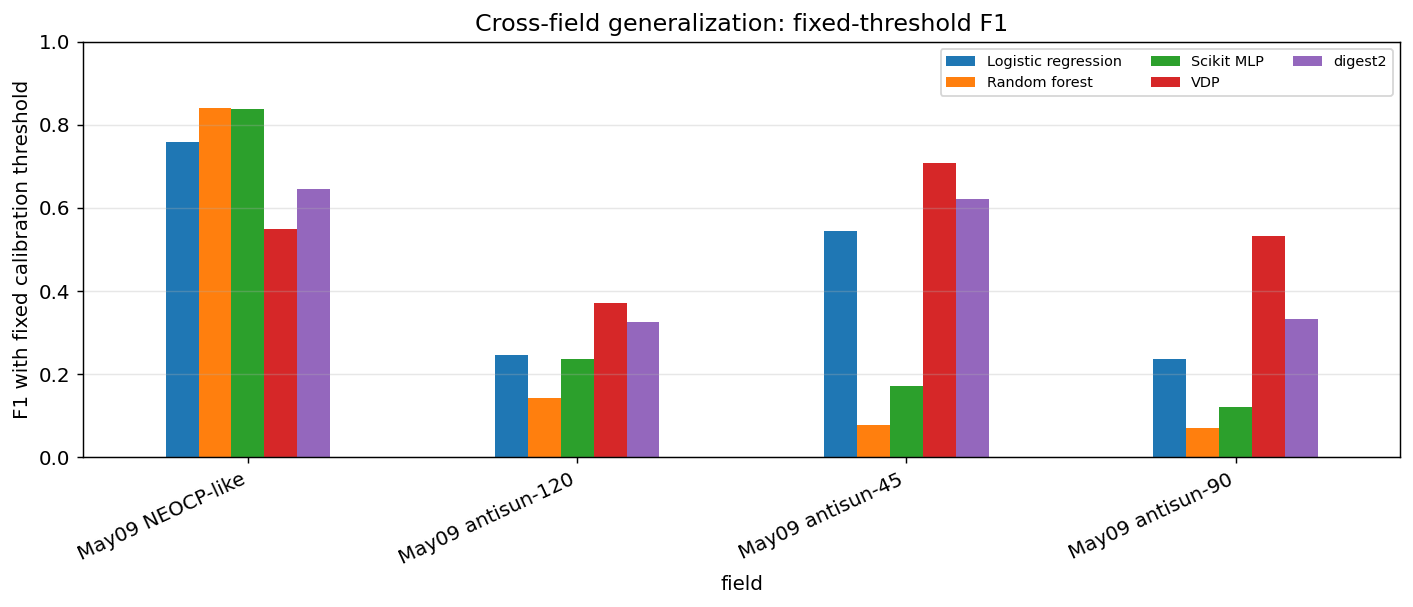

In [8]:
f1_pivot = fixed_summary.pivot(index="field", columns="classifier", values="F1")[CLASSIFIER_ORDER]
display(f1_pivot.style.format("{:.3f}"))

fig, ax = plt.subplots(figsize=(11, 4.8))
f1_pivot[["Logistic regression", "Random forest", "Scikit MLP", "VDP", "digest2"]].plot(kind="bar", ax=ax)
ax.set_ylabel("F1 with fixed calibration threshold")
ax.set_title("Cross-field generalization: fixed-threshold F1")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=8, ncol=3)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 9. Completeness vs Contamination Curves

These curves still scan thresholds on each field, so they show ranking behavior and possible operating points. The fixed-threshold points from calibration are overplotted as markers.

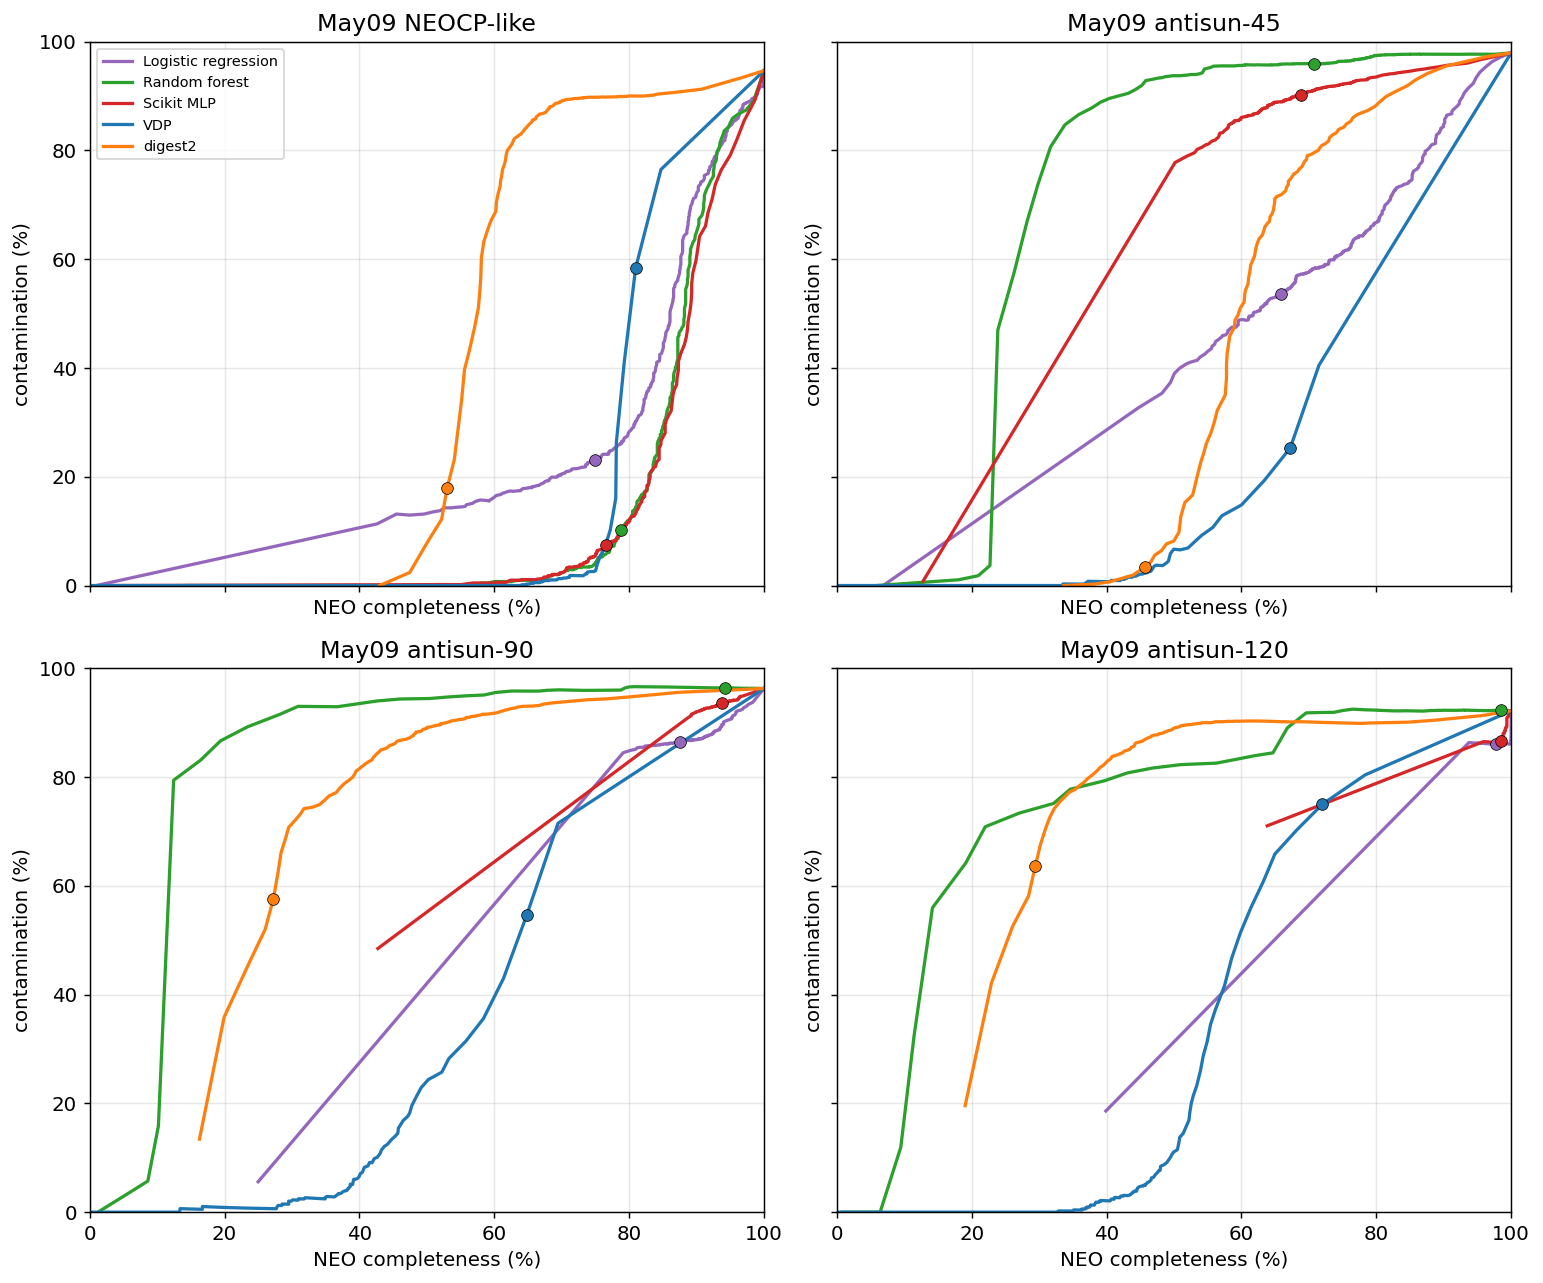

In [9]:
colors = {
    "Dummy": "0.6",
    "Logistic regression": "tab:purple",
    "Random forest": "tab:green",
    "Scikit MLP": "tab:red",
    "VDP": "tab:blue",
    "digest2": "tab:orange",
}
plot_classifiers = ["Logistic regression", "Random forest", "Scikit MLP", "VDP", "digest2"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, field_label in zip(axes, TEST_FIELDS.keys()):
    for name in plot_classifiers:
        curve = all_curves[(field_label, name)]
        ax.plot(curve["completeness"] * 100, curve["contamination"] * 100,
                lw=1.8, label=name, color=colors[name])

        row = fixed_summary[(fixed_summary["field"] == field_label) & (fixed_summary["classifier"] == name)].iloc[0]
        ax.scatter(row["completeness"] * 100, row["contamination"] * 100,
                   s=42, color=colors[name], edgecolor="black", linewidth=0.4, zorder=5)

    ax.set_title(field_label)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.3)
    ax.set_xlabel("NEO completeness (%)")
    ax.set_ylabel("contamination (%)")

axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 10. Field-Best Diagnostic Table

This table is more optimistic because it chooses the best F1 threshold separately on each test field. It is useful for diagnosing ranking quality, but the fixed-threshold table is the stricter generalization result.

In [10]:
best_display = best_summary.sort_values(["field", "F1"], ascending=[True, False]).reset_index(drop=True)
display(best_display.style.format({
    "threshold": "{:.3f}",
    "completeness": "{:.1%}",
    "contamination": "{:.1%}",
    "purity": "{:.1%}",
    "F1": "{:.3f}",
}))

,field,classifier,threshold_source,threshold,completeness,contamination,purity,F1,selected,TP,FP,N_test,N_NEO
0,May09 NEOCP-like,VDP,field-best diagnostic,0.030,75.0%,2.7%,97.3%,0.847,862,839,23,21027,1119
1,May09 NEOCP-like,Random forest,field-best diagnostic,0.782,77.0%,6.1%,93.9%,0.846,918,862,56,21027,1119
2,May09 NEOCP-like,Scikit MLP,field-best diagnostic,0.380,78.1%,8.3%,91.7%,0.844,953,874,79,21027,1119
3,May09 NEOCP-like,Logistic regression,field-best diagnostic,0.755,76.9%,24.1%,75.9%,0.764,1135,861,274,21027,1119
4,May09 NEOCP-like,digest2,field-best diagnostic,0.963,52.2%,12.2%,87.8%,0.655,665,584,81,21027,1119
5,May09 NEOCP-like,Dummy,field-best diagnostic,0.000,100.0%,94.7%,5.3%,0.101,21027,1119,19908,21027,1119
6,May09 antisun-120,VDP,field-best diagnostic,0.060,50.5%,11.5%,88.5%,0.643,801,709,92,17964,1404
7,May09 antisun-120,Logistic regression,field-best diagnostic,1.000,39.9%,18.6%,81.4%,0.535,688,560,128,17964,1404
8,May09 antisun-120,Scikit MLP,field-best diagnostic,1.000,63.8%,71.0%,29.0%,0.398,3094,896,2198,17964,1404
9,May09 antisun-120,digest2,field-best diagnostic,0.963,28.4%,58.1%,41.9%,0.339,953,399,554,17964,1404


## 11. Interpretation Notes

This notebook performs a cross-field generalization test:

```text
train/calibrate on one S3M comparison field
apply unchanged models and thresholds to separate May 9, 2026 fields
compare against VDP and digest2 on the same external objects
```

This is stronger than a random 50/50 split because the test fields have different sky directions, object mixtures, and apparent-magnitude ranges.

What to look for:

- If a scikit model performs well on the random split but collapses on May 9 fields, it probably learned field-specific structure.
- If it remains competitive with VDP across May 9 fields, then the motion/magnitude features contain a reusable discriminative signal.
- If VDP is more stable across fields, that supports the Bayesian density-map approach as a geometry-aware classifier.
- digest2 remains a useful benchmark because it is a tracklet-style classifier independent of this training process.

Important caveat: this is still synthetic S3M data. A final project/research comparison should test multiple epochs, multiple centers, and ideally real or archived candidate tracklets when available.